# Các Thông Số Cơ Bản Của Thống Kê Dữ Liệu Nhiều Biến

Notebook này sẽ trình bày cách tính toán các thông số thống kê cơ bản cho dữ liệu nhiều biến (multivariate data), bao gồm vector trung bình, ma trận hiệp phương sai và ma trận tương quan. Dữ liệu đầu vào là một ma trận $n \times p$, trong đó $n$ là số lượng quan sát (items) và $p$ là số lượng biến (variables).

## 1. Import Libraries

In [67]:
from typing import cast
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.patches import Circle
from sklearn.datasets import load_iris
from sklearn.utils import Bunch

## 2. Load Iris dataset

In [ ]:
# Load Iris dataset
iris = cast(Bunch, load_iris(return_X_y=False))

# Ma trận đầu vào n x p (n=150, p=4)
data = iris.data.astype(float)
target = iris.target
target_names = iris.target_names
feature_names = iris.feature_names
n, p = data.shape
print(f"Iris data matrix: {n} observations, {p} variables")
print("Feature names:", feature_names)
print("Target names:", target_names)
print(data[:5])  # xem 5 dòng đầu

Iris data matrix: 150 observations, 4 variables
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


## 3. Calculate Mean Vector 

Vector trung bình $\bar{\mathbf{x}} = [\bar{x}_1, \bar{x}_2, \ldots, \bar{x}_p]^T$ được tính bằng cách lấy trung bình của từng biến: $\bar{x}_j = \frac{1}{n} \sum_{i=1}^{n} x_{ij}$.

In [ ]:
# 3.1: THE GENERAL FUNCTION (HÀM TỔNG QUÁT)
def calculate_mean_vector(input_data):
    """
    Calculate the mean vector for a given 2D data matrix.
    Uses the MLE approach (dividing by the exact number of rows).
    """
    # Get the number of observations (rows) and variables (columns)
    n_items, p_vars = input_data.shape
    
    # Initialize an array of zeros to hold the mean vector
    mean_vec = np.zeros(p_vars, dtype=float)
    
    # Loop through each variable (column)
    for j in range(p_vars):
        col_sum = 0.0
        
        # Loop through each observation (row)
        for i in range(n_items):
            col_sum += input_data[i, j]
            
        # Divide the sum by the number of observations in this specific dataset
        mean_vec[j] = col_sum / n_items
        
    return mean_vec

Đã khởi tạo hàm tính trung bình tổng quát: calculate_mean_vector()


## 3.1 Vector Trung bình Quần thể (Population Mean Vector)

Trong bối cảnh bài toán này, ta giả định toàn bộ 150 quan sát của tập dữ liệu Iris chính là một **Quần thể (Population)**. 
Vector trung bình quần thể, ký hiệu là $\boldsymbol{\mu}$, được tính bằng cách lấy tổng tất cả các giá trị trong quần thể chia cho tổng số phần tử $N$ (ở đây $N = 150$).

In [70]:
print(f"Thực hiện truyền toàn bộ N = {n} quan sát vào hàm tổng quát.")

# Pass the ENTIRE dataset into the function
pop_mean = calculate_mean_vector(data)

print("\nVector Trung bình Quần thể (Population Mean Vector):")
print(pop_mean)

Thực hiện truyền toàn bộ N = 150 quan sát vào hàm tổng quát.

Vector Trung bình Quần thể (Population Mean Vector):
[5.84333333 3.05733333 3.758      1.19933333]


## 3.2 Vector Trung bình Mẫu (Sample Mean Vector)

Trong thực tế, ta chỉ rút ra một mẫu nhỏ từ quần thể. Để tính Thống kê Mẫu ($\mathbf{\bar{x}}$), ta sẽ bốc ngẫu nhiên $30$ quan sát từ tập dữ liệu và truyền **chỉ 30 dòng này** vào đúng cái hàm đã dùng ở trên.

In [71]:
# Set random seed for reproducibility
np.random.seed(42)

# Define the sample size (e.g., 30 observations)
sample_size = 30
print(f"Tiến hành rút ngẫu nhiên n_sample = {sample_size} quan sát từ quần thể.")

# Draw a random subset of indices from the population (without replacement)
sample_indices = np.random.choice(n, size=sample_size, replace=False)

# Extract the actual data rows for the sample
sample_data = data[sample_indices, :]

# Pass ONLY the sample data into the EXACT SAME function
sample_mean = calculate_mean_vector(sample_data)

print("\nVector Trung bình Mẫu (Sample Mean Vector):")
print(sample_mean)
print("\nNhận xét: Vector trung bình mẫu mang giá trị xấp xỉ và đóng vai trò ước lượng cho vector trung bình quần thể.")

Tiến hành rút ngẫu nhiên n_sample = 30 quan sát từ quần thể.

Vector Trung bình Mẫu (Sample Mean Vector):
[5.98       3.04       3.88333333 1.26333333]

Nhận xét: Vector trung bình mẫu mang giá trị xấp xỉ và đóng vai trò ước lượng cho vector trung bình quần thể.


## 4. Tính toán Vector Phương sai (Variance Vector)

**Định nghĩa:** Phương sai mẫu của từng biến phản ánh mức độ phân tán dữ liệu xung quanh giá trị trung bình: $s_j^2 = \frac{1}{n} \sum_{i=1}^{n} (x_{ij} - \bar{x}_j)^2$.

**Note:** - Triển khai theo phương pháp **Ước lượng hợp lý tối đa (Maximum Likelihood Estimation - MLE)** bằng cách chia cho chính xác số quan sát $n$.
- Trong thống kê suy diễn, cách tính này có thể gây ra "chệch" (bias) nhỏ cho mẫu thấp, nhưng nó đảm bảo tính đồng nhất toán học khi tính toán Ma trận Hiệp phương sai trong các bước tiếp theo.

In [72]:
def calculate_variance_vector(input_data, mean_vec):
    """
    Calculate the variance vector for a given 2D data matrix.
    Uses the MLE approach (divides by the exact number of rows 'n').
    """
    # Get the number of observations (rows) and variables (columns)
    n_items, p_vars = input_data.shape
    
    # Initialize an array of zeros to hold the variance vector
    var_vec = np.zeros(p_vars, dtype=float)
    
    # Loop through each variable (column)
    for j in range(p_vars):
        accum = 0.0
        
        # Loop through each observation (row)
        for i in range(n_items):
            diff = input_data[i, j] - mean_vec[j]
            accum += diff * diff
            
        # Divide the sum of squared differences by the exact number of observations
        var_vec[j] = accum / n_items
        
    return var_vec

## 4.1 Vector Phương sai Quần thể (Population Variance Vector)

Trong bối cảnh bài toán này, ta tiếp tục sử dụng toàn bộ 150 quan sát của tập dữ liệu Iris làm **Quần thể (Population)**.
Vector phương sai quần thể được tính bằng cách truyền toàn bộ ma trận dữ liệu `data` và vector trung bình quần thể `pop_mean` vào hàm tổng quát.

In [73]:
print(f"Thực hiện truyền toàn bộ N = {n} quan sát vào hàm tổng quát.")

# Pass the ENTIRE dataset and POPULATION mean into the function
pop_var = calculate_variance_vector(data, pop_mean)

print("\nVector Phương sai Quần thể (Population Variance Vector):")
print(pop_var)

Thực hiện truyền toàn bộ N = 150 quan sát vào hàm tổng quát.

Vector Phương sai Quần thể (Population Variance Vector):
[0.68112222 0.18871289 3.09550267 0.57713289]


## 4.2 Vector Phương sai Mẫu (Sample Variance Vector)

Trong thực tế, ta sử dụng dữ liệu mẫu để ước lượng phương sai của quần thể. Để tính thống kê cho mẫu, ta sử dụng lại tập dữ liệu gồm $30$ quan sát (`sample_data`) và vector trung bình mẫu tương ứng (`sample_mean`) đã được lấy ra ở phần 3.2 để truyền vào hàm tổng quát.

In [74]:
print(f"Sử dụng lại mẫu ngẫu nhiên n_sample = {sample_size} quan sát từ phần 3.2.")

# Pass ONLY the sample data and SAMPLE mean into the EXACT SAME function
sample_var = calculate_variance_vector(sample_data, sample_mean)

print("\nVector Phương sai Mẫu (Sample Variance Vector):")
print(sample_var)

Sử dụng lại mẫu ngẫu nhiên n_sample = 30 quan sát từ phần 3.2.

Vector Phương sai Mẫu (Sample Variance Vector):
[0.69026667 0.14306667 3.27738889 0.63565556]


## 5. Calculate Covariance Matrix

Ma trận hiệp phương sai $S$ đo lường mức độ biến thiên cùng nhau của các biến và được tính bằng: $S_{jk} = \frac{1}{n} \sum_{i=1}^{n} (x_{ij} - \bar{x}_j)(x_{ik} - \bar{x}_k)$.

In [75]:
def calculate_covariance_matrix(input_data, mean_vec):
    """
    Calculate the covariance matrix for a given 2D data matrix.
    Uses the MLE approach (divides by the exact number of rows 'n').
    """
    # Get the number of observations (rows) and variables (columns)
    n_items, p_vars = input_data.shape
    
    # Initialize a p_vars x p_vars matrix with zeros
    cov_mat = np.zeros((p_vars, p_vars), dtype=float)
    
    # Loop through each pair of variables (j, k)
    for j in range(p_vars):
        for k in range(p_vars):
            accum = 0.0
            
            # Loop through each observation (row)
            for i in range(n_items):
                diff_j = input_data[i, j] - mean_vec[j]
                diff_k = input_data[i, k] - mean_vec[k]
                accum += diff_j * diff_k
                
            # Divide the accumulated sum by the exact number of observations
            cov_mat[j, k] = accum / n_items
            
    return cov_mat

## 5.1 Ma trận Hiệp phương sai Quần thể (Population Covariance Matrix)

Ta tính toán ma trận hiệp phương sai cho toàn bộ $150$ quan sát của tập Iris. Ký hiệu ma trận hiệp phương sai quần thể là $\Sigma$ (Sigma).

In [76]:
print(f"Thực hiện truyền toàn bộ N = {n} quan sát vào hàm tổng quát.")

# Pass the ENTIRE dataset and POPULATION mean into the function
pop_cov = calculate_covariance_matrix(data, pop_mean)

print("\nMa trận Hiệp phương sai Quần thể (Population Covariance Matrix - Σ):")
print(pop_cov)

Thực hiện truyền toàn bộ N = 150 quan sát vào hàm tổng quát.

Ma trận Hiệp phương sai Quần thể (Population Covariance Matrix - Σ):
[[ 0.68112222 -0.04215111  1.26582     0.51282889]
 [-0.04215111  0.18871289 -0.32745867 -0.12082844]
 [ 1.26582    -0.32745867  3.09550267  1.286972  ]
 [ 0.51282889 -0.12082844  1.286972    0.57713289]]


## 5.2 Ma trận Hiệp phương sai Mẫu (Sample Covariance Matrix)

Ta sử dụng lại tập dữ liệu gồm $30$ quan sát (`sample_data`) và vector trung bình mẫu (`sample_mean`) đã lấy ở Mục 3.2 để tính toán. Ký hiệu ma trận hiệp phương sai mẫu là $S_n$.

In [77]:
print(f"Sử dụng lại mẫu ngẫu nhiên n_sample = {sample_size} quan sát từ phần 3.2.")

# Pass ONLY the sample data and SAMPLE mean into the EXACT SAME function
sample_cov = calculate_covariance_matrix(sample_data, sample_mean)

print("\nMa trận Hiệp phương sai Mẫu (Sample Covariance Matrix - S_n):")
print(sample_cov)

print("\nSO SÁNH VÀ KẾT LUẬN ")
print("1. Giá trị trên đường chéo chính của các ma trận này khớp hoàn toàn với Vector Phương sai ở Mục 4.")
print("2. Ma trận hiệp phương sai mẫu (S_n) là một ước lượng thống kê xấp xỉ cho ma trận hiệp phương sai quần thể (Σ).")

Sử dụng lại mẫu ngẫu nhiên n_sample = 30 quan sát từ phần 3.2.

Ma trận Hiệp phương sai Mẫu (Sample Covariance Matrix - S_n):
[[ 0.69026667 -0.05086667  1.37066667  0.58293333]
 [-0.05086667  0.14306667 -0.28566667 -0.10753333]
 [ 1.37066667 -0.28566667  3.27738889  1.39138889]
 [ 0.58293333 -0.10753333  1.39138889  0.63565556]]

SO SÁNH VÀ KẾT LUẬN 
1. Giá trị trên đường chéo chính của các ma trận này khớp hoàn toàn với Vector Phương sai ở Mục 4.
2. Ma trận hiệp phương sai mẫu (S_n) là một ước lượng thống kê xấp xỉ cho ma trận hiệp phương sai quần thể (Σ).


## 6. Calculate Correlation Matrix

Ma trận hệ số tương quan $R$ chuẩn hóa hiệp phương sai về khoảng $[-1, 1]$: $R_{jk} = \frac{S_{jk}}{\sqrt{S_{jj} S_{kk}}}$. Ta sẽ tính toán thủ công dựa trên ma trận hiệp phương sai và vector phương sai đã có.

In [78]:
def calculate_correlation_matrix(cov_mat, var_vec):
    """
    Calculate the correlation matrix using the covariance matrix and variance vector.
    Formula: r_jk = Cov(j,k) / sqrt(Var(j) * Var(k))
    """
    # Get the number of variables (p) from the length of the variance vector
    p_vars = len(var_vec)
    
    # Initialize a p_vars x p_vars matrix with zeros
    corr_mat = np.zeros((p_vars, p_vars), dtype=float)
    
    # Loop through each pair of variables (j, k)
    for j in range(p_vars):
        for k in range(p_vars):
            # Calculate the denominator: sqrt(Var(j) * Var(k))
            denom = np.sqrt(var_vec[j] * var_vec[k])
            
            # Prevent division by zero (if a variable has zero variance)
            if denom == 0:
                corr_mat[j, k] = 0.0
            else:
                corr_mat[j, k] = cov_mat[j, k] / denom
                
    return corr_mat

## 6.1 Ma trận Tương quan Quần thể (Population Correlation Matrix)

Ta tính toán ma trận tương quan cho toàn bộ quần thể bằng cách truyền ma trận hiệp phương sai quần thể ($\Sigma$) và vector phương sai quần thể vào hàm. Ma trận tương quan quần thể thường được ký hiệu là $\boldsymbol{\rho}$ (Rho).

In [79]:
print("Sử dụng dữ liệu đầu vào là pop_cov (Mục 5.1) và pop_var (Mục 4.1).")

# Pass the population covariance and population variance into the function
pop_corr = calculate_correlation_matrix(pop_cov, pop_var)

print("\nMa trận Tương quan Quần thể (Population Correlation Matrix - ρ):")
print(pop_corr)

Sử dụng dữ liệu đầu vào là pop_cov (Mục 5.1) và pop_var (Mục 4.1).

Ma trận Tương quan Quần thể (Population Correlation Matrix - ρ):
[[ 1.         -0.11756978  0.87175378  0.81794113]
 [-0.11756978  1.         -0.4284401  -0.36612593]
 [ 0.87175378 -0.4284401   1.          0.96286543]
 [ 0.81794113 -0.36612593  0.96286543  1.        ]]


## 6.2 Ma trận Tương quan Mẫu (Sample Correlation Matrix)

Tương tự, ta truyền ma trận hiệp phương sai mẫu ($S_n$) và vector phương sai mẫu vào hàm tổng quát để tìm ma trận tương quan mẫu, ký hiệu là $R$.

In [80]:
print("Sử dụng dữ liệu đầu vào là sample_cov (Mục 5.2) và sample_var (Mục 4.2).")

# Pass the sample covariance and sample variance into the function
sample_corr = calculate_correlation_matrix(sample_cov, sample_var)

print("\nMa trận Tương quan Mẫu (Sample Correlation Matrix - R):")
print(sample_corr)

print("\nKẾT LUẬN")
print("1. Đường chéo chính của cả hai ma trận tương quan đều bằng 1.0 (vì một biến luôn tương quan tuyệt đối 100% với chính nó).")
print("2. Các giá trị khác 1 nằm trong khoảng [-1, 1], thể hiện cả chiều hướng (âm/dương) và sức mạnh của mối quan hệ tuyến tính giữa 2 biến.")

Sử dụng dữ liệu đầu vào là sample_cov (Mục 5.2) và sample_var (Mục 4.2).

Ma trận Tương quan Mẫu (Sample Correlation Matrix - R):
[[ 1.         -0.16186599  0.91129589  0.88003413]
 [-0.16186599  1.         -0.41718276 -0.35658491]
 [ 0.91129589 -0.41718276  1.          0.96399242]
 [ 0.88003413 -0.35658491  0.96399242  1.        ]]

KẾT LUẬN
1. Đường chéo chính của cả hai ma trận tương quan đều bằng 1.0 (vì một biến luôn tương quan tuyệt đối 100% với chính nó).
2. Các giá trị khác 1 nằm trong khoảng [-1, 1], thể hiện cả chiều hướng (âm/dương) và sức mạnh của mối quan hệ tuyến tính giữa 2 biến.


## 7. Visualize Summary Statistics

Biểu diễn trực quan giúp nhận biết nhanh các mẫu hình giữa các biến. Ở đây ta minh họa:
- Biểu đồ cột cho vector trung bình và phương sai.
- Heatmap cho ma trận hiệp phương sai và hệ số tương quan.

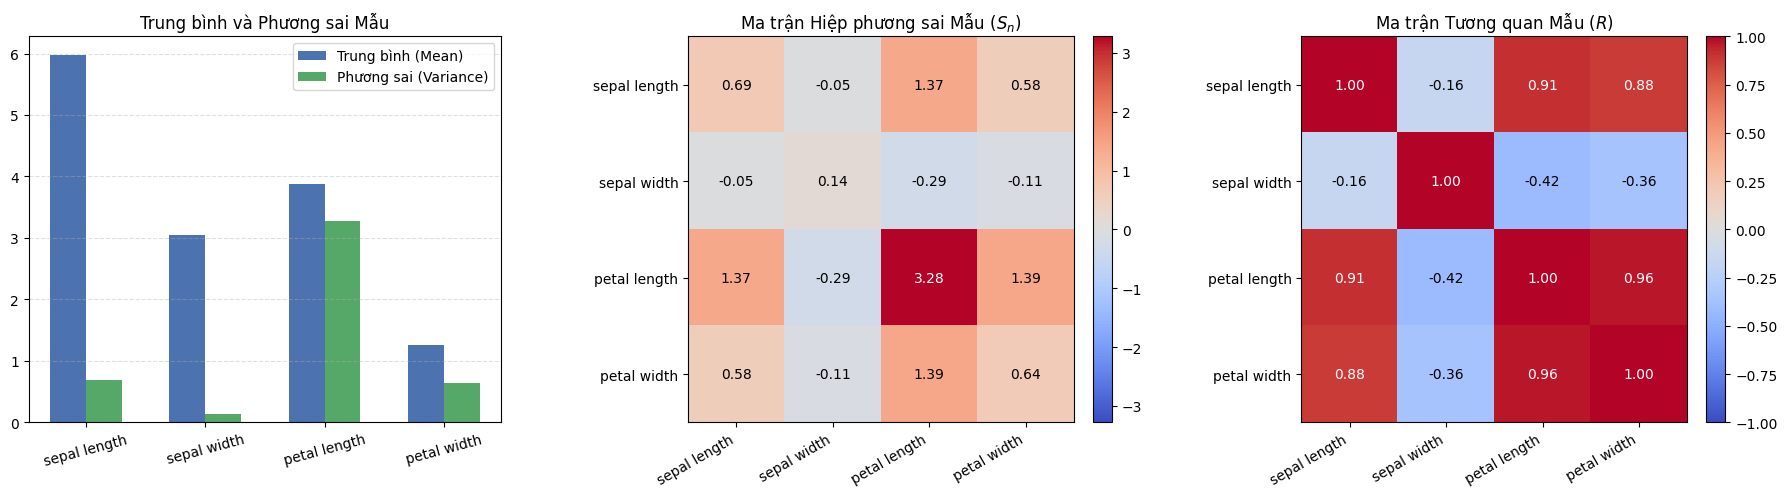

In [81]:
# Create a 1x3 grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Process labels to make them cleaner (e.g., removing "(cm)" if present)
var_labels = [name.replace(" (cm)", "") for name in feature_names]
positions = np.arange(p)

# CHART 1: Bar chart to compare Sample Mean vs Variance
axes[0].bar(positions - 0.15, sample_mean, width=0.3, label="Trung bình (Mean)", color="#4C72B0")
axes[0].bar(positions + 0.15, sample_var, width=0.3, label="Phương sai (Variance)", color="#55A868")
axes[0].set_xticks(positions)
axes[0].set_xticklabels(var_labels, rotation=15)
axes[0].set_title("Trung bình và Phương sai Mẫu")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# CHART 2 & 3: Heatmaps for Sample Covariance and Correlation
heatmap_targets = [
    (sample_cov, "Ma trận Hiệp phương sai Mẫu ($S_n$)"),
    (sample_corr, "Ma trận Tương quan Mẫu ($R$)")
]

# Unpack the remaining two axes and zip with target matrices
for ax, (matrix, title) in zip(axes[1:], heatmap_targets):
    
    # Calculate a symmetric scale for the colormap to center white at 0
    scale = np.max(np.abs(matrix)) or 1.0
    im = ax.imshow(matrix, cmap="coolwarm", vmin=-scale, vmax=scale)
    
    # Format ticks and labels
    ax.set_xticks(positions)
    ax.set_yticks(positions)
    ax.set_xticklabels(var_labels, rotation=30, ha="right")
    ax.set_yticklabels(var_labels)
    ax.set_title(title)
    
    # Annotate each cell with its numerical value
    for row in range(p):
        for col in range(p):
            value = matrix[row, col]
            # Use white text for dark backgrounds, black for light backgrounds
            text_color = "white" if abs(value) > scale * 0.5 else "black"
            ax.text(col, row, f"{value:.2f}", ha="center", va="center", color=text_color)
            
    # Add a colorbar to the side of the heatmap
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 9. Advanced Multivariate Visualizations (Iris)

Phần này minh họa thêm các kỹ thuật trực quan hóa dữ liệu nhiều biến trên Iris dataset:

- Dot diagrams + scatter plot
- Multiple scatter plot (scatter matrix)
- 3D scatter plot theo nhóm
- Stars
- Chernoff faces

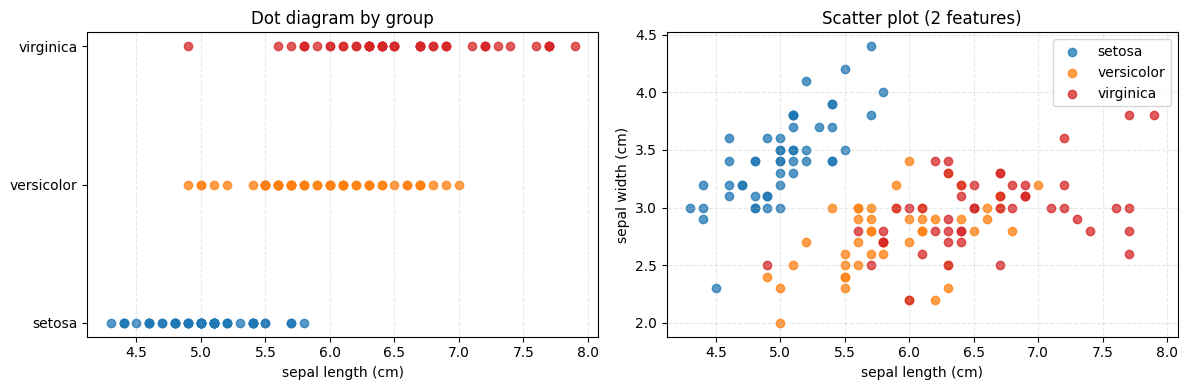

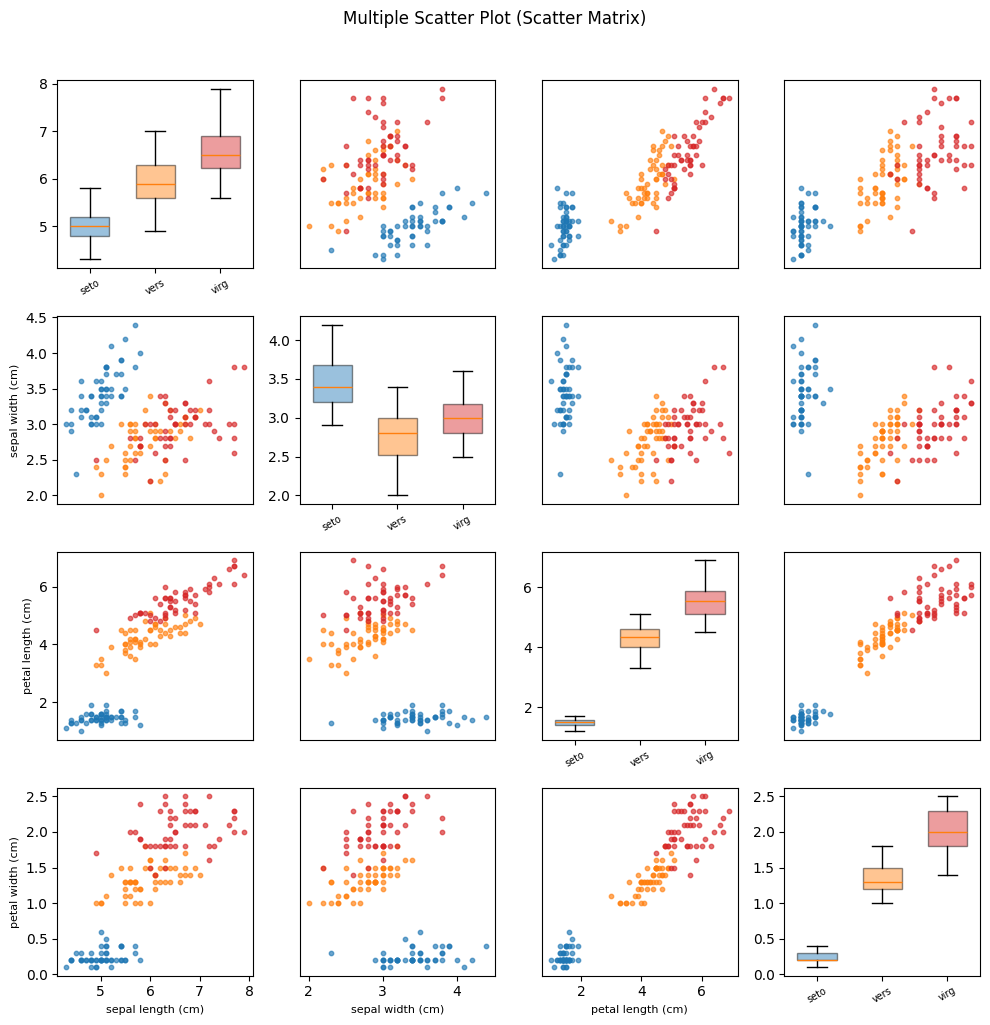

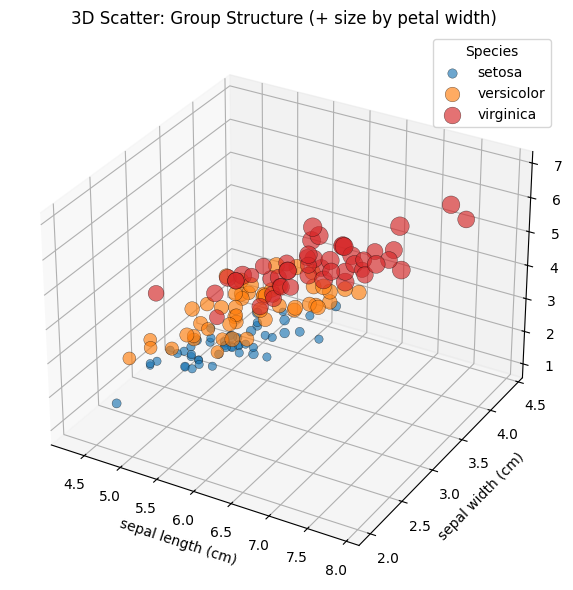

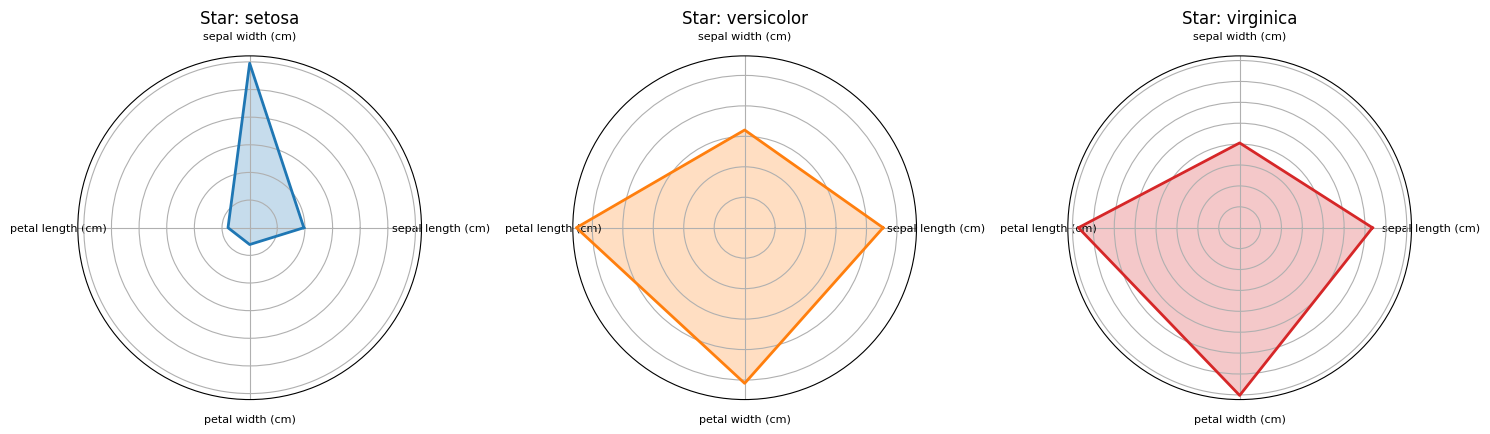

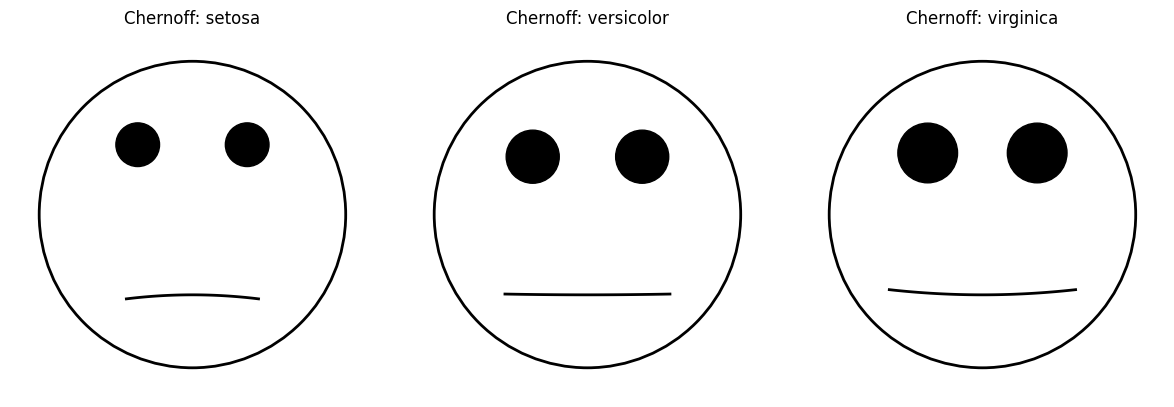

In [83]:
# Chuẩn hóa dữ liệu về [0, 1] để dùng cho nhiều biểu đồ dạng profile
mins = data.min(axis=0)
maxs = data.max(axis=0)
ranges = maxs - mins
ranges[ranges == 0] = 1.0
data_norm = (data - mins) / ranges

# setosa: xanh dương, versicolor: cam, virginica: đỏ
colors = ["#1f77b4", "#ff7f0e", "#d62728"]
labels = [target_names[i] for i in target]

# 1) Dot diagrams + Scatter plot (2 biến đầu)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes_arr = axes if isinstance(axes, np.ndarray) else np.array([axes], dtype=object)
for g, color in enumerate(colors):
    mask = target == g
    axes_arr[0].scatter(data[mask, 0], np.full(mask.sum(), g), alpha=0.75, color=color, label=target_names[g])
axes_arr[0].set_xlabel(feature_names[0])
axes_arr[0].set_yticks([0, 1, 2])
axes_arr[0].set_yticklabels(target_names)
axes_arr[0].set_title("Dot diagram by group")
axes_arr[0].grid(axis="x", linestyle="--", alpha=0.3)

for g, color in enumerate(colors):
    mask = target == g
    axes_arr[1].scatter(data[mask, 0], data[mask, 1], alpha=0.75, color=color, label=target_names[g])
axes_arr[1].set_xlabel(feature_names[0])
axes_arr[1].set_ylabel(feature_names[1])
axes_arr[1].set_title("Scatter plot (2 features)")
axes_arr[1].legend()
axes_arr[1].grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Multiple scatter plot (scatter matrix thủ công, đường chéo là boxplot)
num_features = data.shape[1]
fig, axes = plt.subplots(num_features, num_features, figsize=(10, 10))
axes_grid = axes if isinstance(axes, np.ndarray) else np.array([[axes]], dtype=object)
for i in range(num_features):
    for j in range(num_features):
        ax = axes_grid[i, j]
        if i == j:
            grouped_vals = [data[target == g, j] for g in range(len(target_names))]
            bp = ax.boxplot(grouped_vals, patch_artist=True, widths=0.6, showfliers=False)
            for patch, color in zip(bp["boxes"], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.45)
            ax.set_xticks([1, 2, 3])
            ax.set_xticklabels([name[:4] for name in target_names], fontsize=7, rotation=30)
        else:
            for g, color in enumerate(colors):
                mask = target == g
                ax.scatter(data[mask, j], data[mask, i], s=10, alpha=0.65, color=color)
        if i == num_features - 1 and i != j:
            ax.set_xlabel(feature_names[j], fontsize=8)
        elif i != j:
            ax.set_xticks([])
        if j == 0 and i != j:
            ax.set_ylabel(feature_names[i], fontsize=8)
        elif i != j:
            ax.set_yticks([])
plt.suptitle("Multiple Scatter Plot (Scatter Matrix)", y=1.02)
plt.tight_layout()
plt.show()

# 3) 3D scatter plot (group structure) + biến thứ 4 bằng kích thước điểm
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")

size_raw = data[:, 3]  # petal width (biến thứ 4)
size_span = np.max(size_raw) - np.min(size_raw)
if size_span == 0:
    size_scaled = np.full(n, 80.0)
else:
    size_scaled = 30.0 + (size_raw - np.min(size_raw)) * (180.0 - 30.0) / size_span

for g, color in enumerate(colors):
    mask = target == g
    marker_sizes = size_scaled[mask].astype(float).tolist()
    ax.scatter(
        data[mask, 0], data[mask, 1], data[mask, 2],
        s=marker_sizes,
        color=color,
        alpha=0.65,
        edgecolor="black",
        linewidth=0.3,
        label=target_names[g]
    )

ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.set_zlabel(feature_names[2])
ax.set_title("3D Scatter: Group Structure (+ size by petal width)")
ax.legend(title="Species")
plt.tight_layout()
plt.show()

# 4) Stars (star glyphs cho trung bình từng nhóm)
angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False)
angles_closed = np.concatenate([angles, [angles[0]]])

fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={"projection": "polar"})
axes_arr = axes if isinstance(axes, np.ndarray) else np.array([axes], dtype=object)
for g, ax in enumerate(axes_arr):
    mean_profile = data_norm[target == g].mean(axis=0)
    values = np.concatenate([mean_profile, [mean_profile[0]]])
    ax.plot(angles_closed, values, color=colors[g], linewidth=2)
    ax.fill(angles_closed, values, color=colors[g], alpha=0.25)
    ax.set_xticks(angles)
    ax.set_xticklabels(feature_names, fontsize=8)
    ax.set_yticklabels([])
    ax.set_title(f"Star: {target_names[g]}")
plt.tight_layout()
plt.show()

# 5) Chernoff Faces (vẽ mặt đơn giản từ 4 biến đã chuẩn hóa)
def draw_face(ax: Axes, values, title=""):
    # values gồm 4 phần tử trong [0, 1]
    eye_size = 0.05 + 0.05 * values[0]
    eye_y = 0.62 + 0.12 * values[1]
    mouth_curve = -0.4 + 0.8 * values[2]
    mouth_width = 0.35 + 0.2 * values[3]

    face = Circle((0.5, 0.5), 0.42, fill=False, linewidth=2)
    ax.add_patch(face)

    left_eye = Circle((0.35, eye_y), eye_size, color="black")
    right_eye = Circle((0.65, eye_y), eye_size, color="black")
    ax.add_patch(left_eye)
    ax.add_patch(right_eye)

    xs = np.linspace(0.5 - mouth_width / 2, 0.5 + mouth_width / 2, 100)
    ys = 0.28 + mouth_curve * (xs - 0.5) ** 2
    ax.plot(xs, ys, color="black", linewidth=2)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

group_means = np.array([data_norm[target == g].mean(axis=0) for g in range(3)])
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes_arr = axes if isinstance(axes, np.ndarray) else np.array([axes], dtype=object)
for g, ax in enumerate(axes_arr):
    draw_face(ax, group_means[g], title=f"Chernoff: {target_names[g]}")
plt.tight_layout()
plt.show()

## 10. t-SNE Visualization

t-SNE (t-distributed Stochastic Neighbor Embedding) giúp biểu diễn dữ liệu nhiều chiều về 2D để quan sát cấu trúc nhóm. Vì t-SNE nhạy với scale, ta chuẩn hóa dữ liệu trước khi giảm chiều.

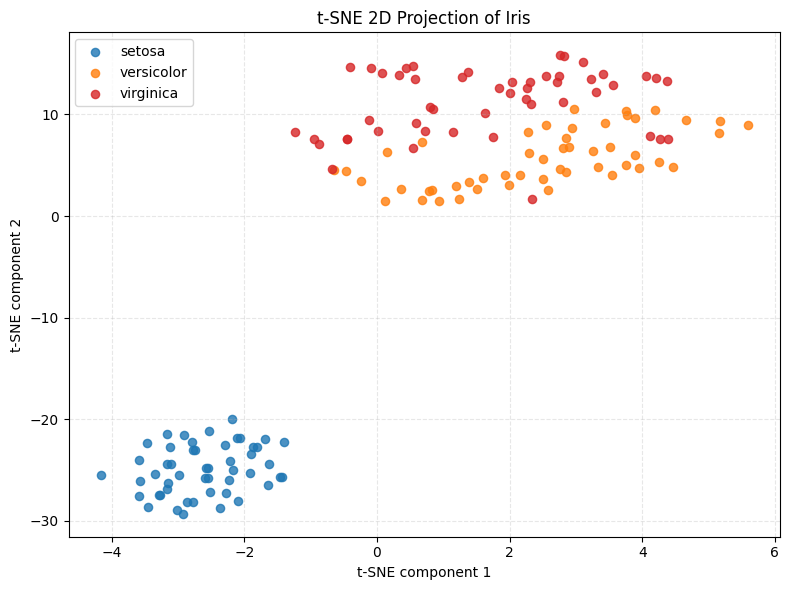

In [84]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa trước khi chạy t-SNE
X_scaled = StandardScaler().fit_transform(data)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42
    )
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for g, color in enumerate(colors):
    mask = target == g
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        color=color, alpha=0.8, s=35, label=target_names[g]
    )
ax.set_title("t-SNE 2D Projection of Iris")
ax.set_xlabel("t-SNE component 1")
ax.set_ylabel("t-SNE component 2")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Độ đo Khoảng cách Thống kê (Mahalanobis Distance)

**Vấn đề:** Khoảng cách Euclidean thông thường bỏ qua sự khác biệt về thang đo và sự tương quan giữa các biến (ví dụ: chiều dài và chiều rộng cánh hoa thường biến thiên cùng nhau).

**Giải pháp:** Khoảng cách Mahalanobis chuẩn hóa dữ liệu dựa trên ma trận hiệp phương sai:
$$D = \sqrt{(\mathbf{x} - \mathbf{\bar{x}})^T S^{-1} (\mathbf{x} - \mathbf{\bar{x}})}$$

**Kỹ thuật lập trình:** - Sử dụng **Nghịch đảo giả (Moore-Penrose Pseudo-inverse - `pinv`)** thay vì nghịch đảo thông thường để đảm bảo tính ổn định hệ thống (Robustness), tránh lỗi nếu dữ liệu có các biến phụ thuộc tuyến tính (ma trận suy biến).

In [85]:
def calculate_statistical_distance(x, mean_vec, cov_mat):
    """
    Calculate Mahalanobis distance for a single observation vector.
    Use pseudo-inverse (pinv) to prevent errors if the matrix is singular.
    """
    # Calculate the difference vector
    diff = x - mean_vec
    
    # Calculate the inverse of the covariance matrix
    inv_cov = np.linalg.pinv(cov_mat)
    
    # Calculate D^2 = diff^T * S^-1 * diff
    dist_squared = np.dot(np.dot(diff.T, inv_cov), diff)
    
    # Return the square root for the actual distance
    return np.sqrt(dist_squared)

print("Khoảng cách thống kê cho 5 quan sát đầu tiên trong tập dữ liệu Iris:")
print("-" * 65)
print(f"{'Chỉ số (Index)':<15} | {'Khoảng cách Euclidean':<25} | {'Khoảng cách Thống kê'}")
print("-" * 65)

# Iterate through the first 5 rows of the dataset
for i in range(5):
    obs = data[i]
    
    # Calculate standard Euclidean distance (ignores correlation)
    euclidean_dist = np.linalg.norm(obs - sample_mean)
    
    # Calculate Statistical distance (accounts for correlation and scale)
    stat_dist = calculate_statistical_distance(obs, sample_mean, sample_cov)
    
    print(f"Quan sát {i:<6} | {euclidean_dist:<25.4f} | {stat_dist:.4f}")
print("-" * 65)

Khoảng cách thống kê cho 5 quan sát đầu tiên trong tập dữ liệu Iris:
-----------------------------------------------------------------
Chỉ số (Index)  | Khoảng cách Euclidean     | Khoảng cách Thống kê
-----------------------------------------------------------------
Quan sát 0      | 2.8781                    | 1.5548
Quan sát 1      | 2.9096                    | 1.6154
Quan sát 2      | 3.0771                    | 1.5580
Quan sát 3      | 2.9528                    | 1.7753
Quan sát 4      | 2.9277                    | 1.7963
-----------------------------------------------------------------


## 12. Đặc tính Mẫu lớn: Luật Số Lớn (Law of Large Numbers)

**Thực nghiệm:** Chúng ta coi tập dữ liệu Iris (150 mẫu) là một "Quần thể" cố định. Sau đó, tiến hành rút mẫu ngẫu nhiên có hoàn lại (Bootstrap) với kích thước $N$ tăng dần từ 10 đến 10,000.

**Kỳ vọng:** Theo LLN, sai số giữa các thống kê mẫu (Mean, Covariance) và tham số quần thể thực phải hội tụ về 0.

**Trực quan hóa:** Sử dụng **Thang đo Logarit (Logarithmic Scale)** cho trục hoành để quan sát rõ nét tốc độ hội tụ ở cả giai đoạn mẫu nhỏ và mẫu cực lớn.

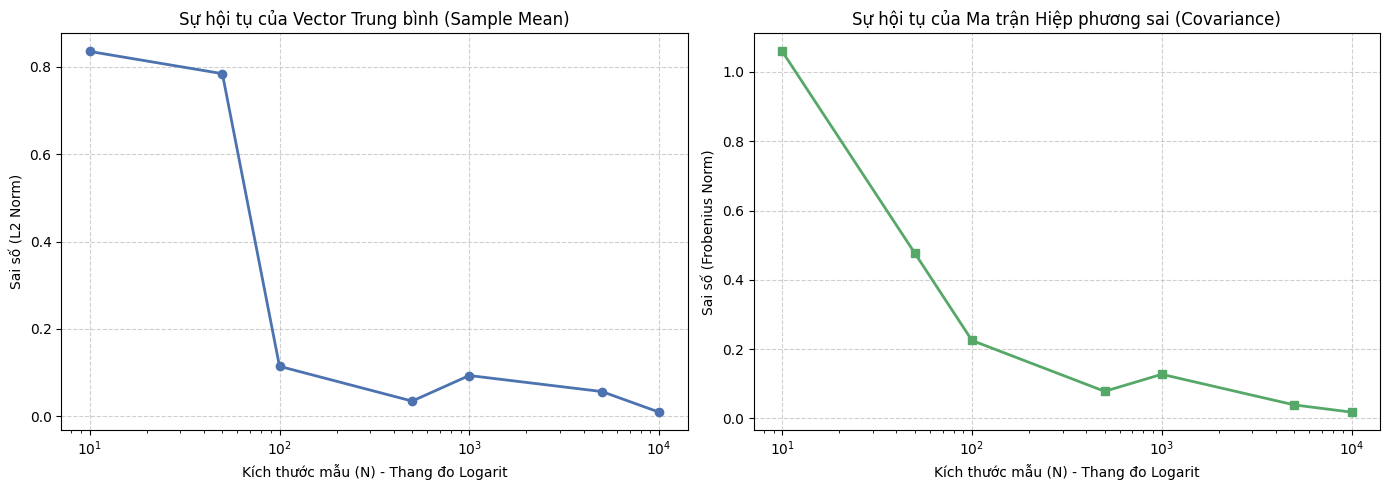

In [86]:
# Define sample sizes to simulate convergence
sample_sizes = [10, 50, 100, 500, 1000, 5000, 10000]

# Lists to store calculation errors
mean_errors = []
cov_errors = []

for size in sample_sizes:
    # Randomly draw indices with replacement from the Iris dataset
    random_indices = np.random.choice(n, size=size, replace=True)
    
    # Extract the bootstrap sample based on indices
    sample_data = data[random_indices, :]
    
    # Calculate sample statistics
    sample_mean = np.mean(sample_data, axis=0)
    # Use ddof=0 to strictly match the Maximum Likelihood Estimation (MLE) formula
    sample_cov = np.cov(sample_data, rowvar=False, ddof=0)
    
    # Calculate difference between sample statistics and true population parameters
    err_mean = np.linalg.norm(sample_mean - pop_mean)
    err_cov = np.linalg.norm(sample_cov - pop_cov)
    
    # Store errors for visualization
    mean_errors.append(err_mean)
    cov_errors.append(err_cov)

# Create a figure with 2 side-by-side subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot the convergence of the Mean Vector
ax[0].plot(sample_sizes, mean_errors, marker='o', color='#4C72B0', linewidth=2)
ax[0].set_xscale('log')
ax[0].set_xlabel('Kích thước mẫu (N) - Thang đo Logarit')
ax[0].set_ylabel('Sai số (L2 Norm)')
ax[0].set_title('Sự hội tụ của Vector Trung bình (Sample Mean)')
ax[0].grid(True, linestyle="--", alpha=0.6)

# Plot the convergence of the Covariance Matrix
ax[1].plot(sample_sizes, cov_errors, marker='s', color='#55A868', linewidth=2)
ax[1].set_xscale('log')
ax[1].set_xlabel('Kích thước mẫu (N) - Thang đo Logarit')
ax[1].set_ylabel('Sai số (Frobenius Norm)')
ax[1].set_title('Sự hội tụ của Ma trận Hiệp phương sai (Covariance)')
ax[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## 13.1. Định lý Giới hạn Trung tâm cho Từng Biến (Univariate CLT)

**Mục tiêu:** Chứng minh rằng dù dữ liệu gốc có phân phối như thế nào (lệch, nhiều đỉnh), trung bình của các mẫu có kích thước đủ lớn ($n \ge 30$) sẽ luôn hội tụ về phân phối Chuẩn.

**Thực hiện:**
1. Rút 2000 mẫu ngẫu nhiên (Bootstrap) từ quần thể Iris.
2. Tính Vector Trung bình cho mỗi mẫu.
3. Vẽ Histogram cho từng biến trong số 4 đặc trưng của hoa Iris.

**Kỳ vọng:** Các biểu đồ Histogram sẽ hiển thị hình dạng "quả chuông" đối xứng, với đỉnh tập trung tại giá trị trung bình của quần thể gốc (đường kẻ đứt màu xanh).

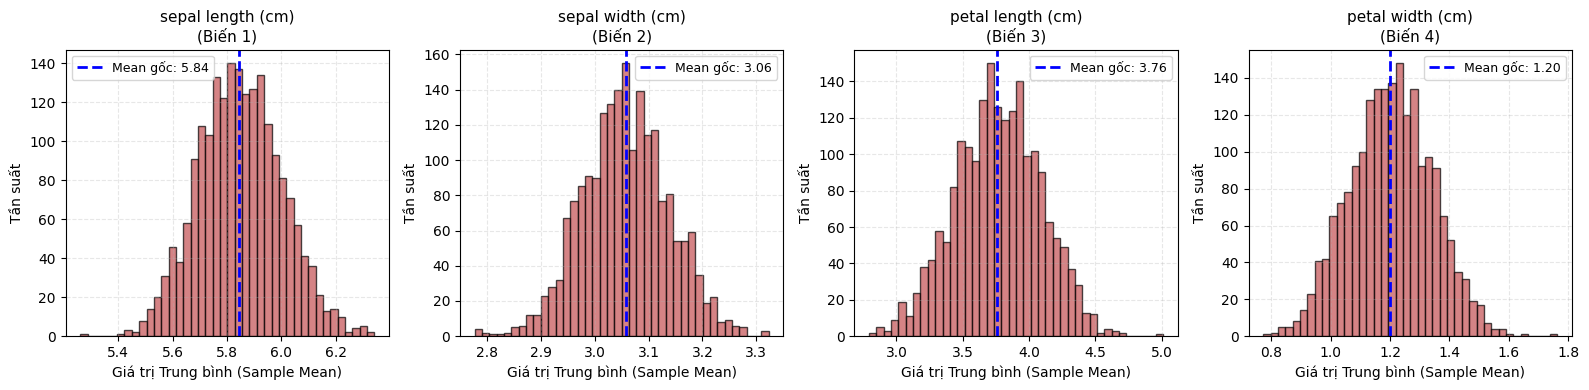

Nhận xét: Mặc dù dữ liệu Iris gốc có đặc tính phân cụm theo 3 loài hoa,
phân phối của các Sample Means ở cả 4 biến đều đối xứng hoàn hảo thành hình quả chuông (Normal Distribution)!


In [87]:
# Setup parameters for the CLT simulation
num_simulations = 2000
n_clt = 30 

# Initialize a matrix to store the mean vectors from all simulations
# Dimension will be 2000 rows by p (4) columns
bootstrap_means = np.zeros((num_simulations, p))

# Set random seed for reproducibility
np.random.seed(42)

for i in range(num_simulations):
    # Select random indices with replacement to form a bootstrap sample
    resample_idx = np.random.choice(n, size=n_clt, replace=True)
    
    # Extract the subset of data
    bootstrap_sample = data[resample_idx, :]
    
    # Calculate and store the mean vector for this specific sample
    bootstrap_means[i, :] = np.mean(bootstrap_sample, axis=0)

# Create dynamic subplots based on the number of features (p)
fig, axes = plt.subplots(1, p, figsize=(4 * p, 4))
axes_arr = axes if isinstance(axes, np.ndarray) else np.array([axes], dtype=object)

for j in range(p):
    # Plot a histogram for the j-th feature's sample means
    axes_arr[j].hist(bootstrap_means[:, j], bins=40, color='#C44E52', alpha=0.7, edgecolor='black')
    
    # Draw a vertical line representing the true population mean
    axes_arr[j].axvline(pop_mean[j], color='blue', linestyle='--', linewidth=2, 
                    label=f'Mean gốc: {pop_mean[j]:.2f}')
    
    # Set titles and labels in Vietnamese
    axes_arr[j].set_title(f"{feature_names[j]}\n(Biến {j+1})", fontsize=11)
    axes_arr[j].set_xlabel("Giá trị Trung bình (Sample Mean)")
    axes_arr[j].set_ylabel("Tần suất")
    axes_arr[j].legend(fontsize=9)
    axes_arr[j].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print("Nhận xét: Mặc dù dữ liệu Iris gốc có đặc tính phân cụm theo 3 loài hoa,")
print("phân phối của các Sample Means ở cả 4 biến đều đối xứng hoàn hảo thành hình quả chuông (Normal Distribution)!")

## 13.2. Định lý Giới hạn Trung tâm Đa biến (Multivariate CLT - 2D)

**Mục tiêu:** Mở rộng quan sát từ 1D sang không gian 2D để thấy được sự hình thành của **Phân phối Chuẩn Hai Chiều (Bivariate Normal Distribution)**.

**Ý nghĩa hình học:** - Trong không gian đa chiều, CLT không chỉ tạo ra hình chuông mà tạo ra một **đám mây mật độ hình Elip**. 
- Độ dẹt và hướng xoay của elip này phản ánh chính xác Ma trận Hiệp phương sai của các trung bình mẫu.

**Trực quan hóa:** Sử dụng biểu đồ mật độ 2D (2D Histogram) cho cặp biến *Sepal Length* và *Sepal Width*. Màu càng đậm thể hiện tần suất xuất hiện của trung bình mẫu tại khu vực đó càng cao.

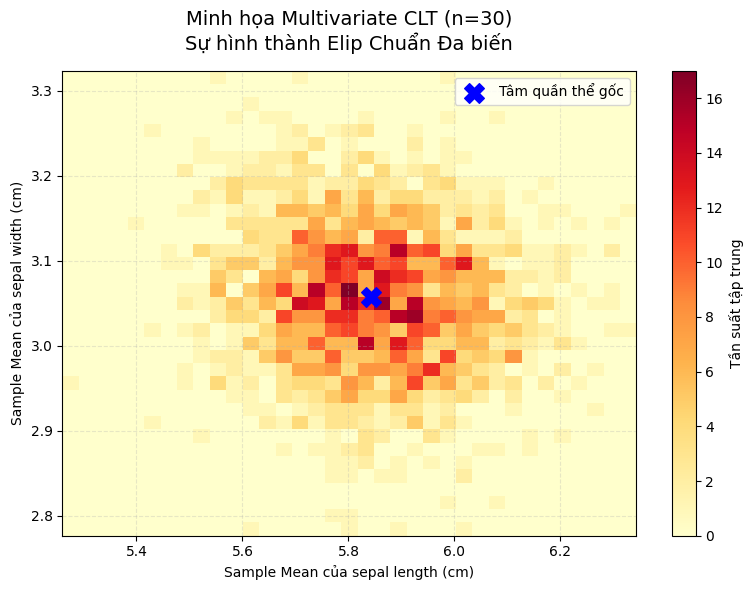

Nhận xét hình học (13.2):
- Khi kết hợp 2 biến ngẫu nhiên, ta không chỉ có hình chuông mà có một ĐÁM MÂY ĐIỂM HÌNH ELIP.
- Hình Elip này có mật độ dày đặc ở tâm (chỗ màu đỏ đậm) và nhạt dần ra xung quanh, chính là bề mặt của Phân phối Chuẩn Đa Biến (Bivariate Normal Distribution).
- Trục nghiêng của Elip thể hiện chiều hướng của Hiệp phương sai (Covariance) giữa 2 biến mẫu.


In [88]:
# Select 2 variables to observe their correlation (e.g., Sepal length and Sepal width)
var1_idx = 0
var2_idx = 1

fig, ax = plt.subplots(figsize=(8, 6))

# Plot a 2D Histogram to show the density of the Sample Mean Vectors
h = ax.hist2d(
    bootstrap_means[:, var1_idx], 
    bootstrap_means[:, var2_idx], 
    bins=35, 
    cmap='YlOrRd'  # Color scale from Yellow to Red (indicating density)
)

# Mark the True Population Mean with a large X
ax.scatter(
    pop_mean[var1_idx], 
    pop_mean[var2_idx], 
    color='blue', marker='X', s=200, label='Tâm quần thể gốc'
)

# Align and format the plot
ax.set_title(f"Minh họa Multivariate CLT (n=30)\nSự hình thành Elip Chuẩn Đa biến", fontsize=14, pad=15)
ax.set_xlabel(f"Sample Mean của {feature_names[var1_idx]}")
ax.set_ylabel(f"Sample Mean của {feature_names[var2_idx]}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

# Add a colorbar to annotate the frequency
fig.colorbar(h[3], ax=ax, label="Tần suất tập trung")

plt.tight_layout()
plt.show()

# Print concluding geometric remarks for the report
print("Nhận xét hình học (13.2):")
print("- Khi kết hợp 2 biến ngẫu nhiên, ta không chỉ có hình chuông mà có một ĐÁM MÂY ĐIỂM HÌNH ELIP.")
print("- Hình Elip này có mật độ dày đặc ở tâm (chỗ màu đỏ đậm) và nhạt dần ra xung quanh, chính là bề mặt của Phân phối Chuẩn Đa Biến (Bivariate Normal Distribution).")
print("- Trục nghiêng của Elip thể hiện chiều hướng của Hiệp phương sai (Covariance) giữa 2 biến mẫu.")